# 흉부 X-ray 폐렴 진단 모델 변환 #1 : 포멧 추출

과제식별: [스프린트 미션16](https://www.codeit.kr/topics/studyGroupStep6985c0c3b71ad43b08e455fa/lessons/14112)  
작성: 2026.07.15 신호정

## A. 프로젝트의 목적

### A-a. 수행 방향

- 대상 모델 선정
    - 미션 06 흉부 X-ray 폐렴 진단에서 사용한 MobileNetV3-Large 를 사용합니다.
- 목표
    - 최고 성능 재현이 아니라 **포맷 변환 파이프라인 검증용 기준 모델**을 확보합니다.
    - 이후 아래 3종 포맷으로 추출하고 각 포맷의 동작과 성능을 검증하겠습니다.

| 산출 포맷 | 파일명 | 방식 |
|---|---|---|
| PyTorch FP32 | `mission_16_mobilenetv3.pth` | `state_dict` 저장 |
| PyTorch INT8 | `mission_16_mobilenetv3_quant.pth` | PTQ(정적 양자화) 후 TorchScript 저장 |
| ONNX | `mission_16_mobilenetv3.onnx` | opset 17, Fixed Shape `(1, 3, 224, 224)` |

### A-b. 평가 원칙

의료 도메인이므로 accuracy 단독으로 판단하지 않습니다. (미션 06의 방침과 동일)  
**Recall(폐렴)과 FN(위음성) 개수를 우선**으로 보며,  
양자화 전후의 FN 변화를 주요 비교 대상으로 삼습니다.

### A-c. 구성

| 섹션 | 내용 |
|---|---|
| B | 환경 설정 및 데이터 준비 |
| C | 모델 학습 (기준 FP32 모델) |
| D | FP32 `.pth` 추출 |
| E | INT8 양자화 `.pth` 추출 (PTQ) |
| F | ONNX 추출 및 검증 |

## B. 환경 설정 및 데이터 준비

### B-a. 계획 확인

- 데이터: 미션 06과 동일한 `Kaggle Chest X-Ray Pneumonia` 를 사용합니다.
  로컬 절대경로를 기본으로 하고, Colab 실행 시 `kagglehub`로 분기처리 합니다.

- 난수 고정: `SEED = 42` (random / numpy / torch / torch.cuda).

- 전처리: 미션 06과 동일하게 처리합니다.
  - 그레이스케일 로드
  - CLAHE(clip 2.0, tile 8×8)
  - 가로세로비 유지 검은색 패딩
  - 224×224 리사이즈
  - 3채널 변환
  - ImageNet 정규화

- 증강(train 전용, 미션 06 동일): 회전 ±10°, 스케일 ±5%, 밝기 0.1. 상하/좌우 반전 금지.  
  **대비(contrast) 증강 금지** -> 침윤, 경화 등 방사선학적 소견을 훼손할 수 있기 때문입니다.

- 분할(미션 06 동일): 원본 val은 16장뿐이라 통계적 유의성이 없으므로 train+val 병합 후 8:2로 재분배합니다.
  test 624장은 원본을 유지합니다.

- 클래스 불균형(미션 06 동일, PNEUMONIA 약 74%): 손실 함수에 inverse-frequency 클래스 가중치를 적용합니다.

### B-b. 환경 설정

#### B-b-1. 공용 패키지 임포트

In [1]:
import json
import logging
import os
import random
import sys
import time
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision

# onnxruntime GPU 빌드는 libcudart.so.12를 요구하므로 torch를 먼저 import하여
# torch 동봉 CUDA 런타임이 프로세스에 로드된 뒤에 import한다
import onnx
import onnxruntime as ort
from matplotlib import font_manager
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

print(f"python      : {sys.version.split()[0]}")
print(f"torch       : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"onnx        : {onnx.__version__}")
print(f"onnxruntime : {ort.__version__}")
print(f"opencv      : {cv2.__version__}")

python      : 3.12.13
torch       : 2.10.0+cu128
torchvision : 0.25.0+cu128
onnx        : 1.21.0
onnxruntime : 1.27.1
opencv      : 4.13.0


#### B-b-2. 로깅 및 그래프 한글 폰트 설정

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    stream=sys.stdout,
    force=True,
)
logger = logging.getLogger("mission16")


def register_korean_font() -> None:
    """NanumGothic 폰트를 matplotlib에 등록한다. 없으면 기본 폰트로 진행한다."""
    for font_path in (Path("../NanumGothic.ttf"), Path("NanumGothic.ttf")):
        if font_path.exists():
            font_manager.fontManager.addfont(str(font_path))
            plt.rcParams["font.family"] = "NanumGothic"
            plt.rcParams["axes.unicode_minus"] = False
            logger.info(f"한글 폰트 등록: {font_path}")
            return
    logger.warning("NanumGothic.ttf 미발견 — 기본 폰트로 진행 (한글 라벨이 깨질 수 있음)")


register_korean_font()

[16:33:55] [INFO] 한글 폰트 등록: ../NanumGothic.ttf


#### B-b-3. 난수 고정 및 연산 장치 선택

In [3]:
SEED = 42


def fix_seed(seed: int = SEED) -> None:
    """재현성을 위해 주요 난수 생성기를 모두 고정한다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


fix_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"연산 장치: {device}")
if device.type == "cuda":
    logger.info(f"GPU: {torch.cuda.get_device_name(0)}")

[16:33:55] [INFO] 연산 장치: cuda


[16:33:55] [INFO] GPU: NVIDIA GeForce RTX 5050 Laptop GPU


#### B-b-4. 경로 상수 관리 (Colab 분기 포함)

In [ ]:
try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

CLASS_NAMES = ("NORMAL", "PNEUMONIA")
NUM_CLASSES = len(CLASS_NAMES)

LOCAL_DATA_ROOT = Path("/mnt/wsl_data/datasets/chest-xray-pneumonia/chest-x-ray-images-pneumonia")


def resolve_data_root() -> Path:
    """데이터 루트를 결정한다. 로컬 절대경로 기본, Colab에서는 kagglehub 캐시를 사용한다."""
    if not is_colab:
        return LOCAL_DATA_ROOT

    import kagglehub

    downloaded = Path(kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia"))
    for train_dir in downloaded.rglob("train"):
        if (train_dir.parent / "test").exists():
            return train_dir.parent
    raise FileNotFoundError(f"kagglehub 경로에서 train/test 구조를 찾지 못했습니다: {downloaded}")


DATA_ROOT = resolve_data_root()

for split in ("train", "val", "test"):
    (DATA_ROOT / split).mkdir(exist_ok=True)

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

MODELS_DIR = Path("models")
CKPT_DIR = Path("checkpoints")
for out_dir in (MODELS_DIR, CKPT_DIR):
    out_dir.mkdir(exist_ok=True)

logger.info(f"실행 환경: {'Colab' if is_colab else '로컬(WSL2)'}")
logger.info(f"DATA_ROOT : {DATA_ROOT}")
logger.info(f"MODELS_DIR: {MODELS_DIR.resolve()}")

[16:33:55] [INFO] 실행 환경: 로컬(WSL2)


[16:33:55] [INFO] DATA_ROOT : /mnt/wsl_data/datasets/chest-xray-pneumonia/chest-x-ray-images-pneumonia


[16:33:55] [INFO] MODELS_DIR: /mnt/wsl_data/kdt/missions/mission16/4팀_신호정/models


### B-c. 데이터 준비

#### B-c-1. 전처리 상수 정의 (미션 06 승계)

In [5]:
IMAGE_SIZE = 224

# ImageNet 정규화 파라미터 (사전 학습 모델의 입력 기대값)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# CLAHE 파라미터 (X-ray 밝기·대비 보정)
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID = (8, 8)

# 데이터 증강 파라미터 (해부학적 왜곡 방지 범위, 대비 변형 금지)
AUG_ROTATION_DEG = 10
AUG_SCALE_RANGE = (0.95, 1.05)
AUG_BRIGHTNESS = 0.1

# train+val 재분배 비율
VAL_SPLIT_RATIO = 0.2

logger.info(
    f"전처리 상수 설정 완료: IMAGE_SIZE={IMAGE_SIZE}, "
    f"CLAHE(clip={CLAHE_CLIP_LIMIT}, grid={CLAHE_TILE_GRID})"
)

[16:33:55] [INFO] 전처리 상수 설정 완료: IMAGE_SIZE=224, CLAHE(clip=2.0, grid=(8, 8))


#### B-c-2. Dataset 구현

미션 06 `ChestXrayDataset`을 승계합니다.  
CLAHE는 결정적 보정(전처리)입니다.  
증강 단계에서는 밝기만 허용하고 대비(contrast) 변형은 금지합니다.

In [6]:
def pad_to_square(img: np.ndarray) -> np.ndarray:
    """가로세로비를 유지한 채 검은색 패딩으로 정방형 이미지를 만든다."""
    h, w = img.shape[:2]
    if h == w:
        return img

    max_side = max(h, w)
    padded = np.zeros((max_side, max_side), dtype=img.dtype)
    y_offset = (max_side - h) // 2
    x_offset = (max_side - w) // 2
    padded[y_offset:y_offset + h, x_offset:x_offset + w] = img
    return padded


class ChestXrayDataset(Dataset):
    """흉부 X-ray 폐렴 진단용 Dataset (미션 06 파이프라인 승계).

    전처리 순서:
        1. 그레이스케일 로드
        2. CLAHE 히스토그램 평탄화 (X-ray 밝기·대비 보정)
        3. 가로세로비 유지 패딩 후 224x224 리사이즈
        4. 3채널 변환 (사전 학습 모델 호환)
        5. 증강 (train 전용)
        6. ImageNet 정규화
    """

    def __init__(
        self,
        image_paths: list[Path],
        labels: list[int],
        is_train: bool = False,
    ) -> None:
        if len(image_paths) != len(labels):
            raise ValueError(f"경로({len(image_paths)})와 라벨({len(labels)}) 수가 불일치합니다.")

        self.image_paths = image_paths
        self.labels = labels
        self.is_train = is_train
        self.clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID)

        if is_train:
            self.augment = transforms.Compose([
                transforms.RandomRotation(AUG_ROTATION_DEG),
                transforms.RandomAffine(degrees=0, scale=AUG_SCALE_RANGE),
                transforms.ColorJitter(brightness=AUG_BRIGHTNESS),
            ])
        else:
            self.augment = None

        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        path = str(self.image_paths[idx])
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"이미지 로드 실패: {path}")

        img = self.clahe.apply(img)
        img = pad_to_square(img)
        img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)

        pil_img = Image.fromarray(img).convert("RGB")
        if self.augment is not None:
            pil_img = self.augment(pil_img)

        tensor = self.normalize(self.to_tensor(pil_img))
        return tensor, self.labels[idx]

#### B-c-3. 데이터 재분배 및 Dataset 생성

train+val을 합친 뒤 stratified 80:20으로 재분배하고(test는 원본 유지),  
클래스 불균형 보상용 inverse-frequency 가중치를 계산합니다.

In [7]:
def collect_image_paths_and_labels(*split_dirs: Path) -> tuple[list[Path], list[int]]:
    """분할 디렉터리들에서 이미지 경로와 라벨을 수집한다. macOS 메타데이터 파일은 제외한다."""
    paths: list[Path] = []
    labels: list[int] = []
    excluded = 0

    for split_dir in split_dirs:
        for cls_idx, cls_name in enumerate(CLASS_NAMES):
            cls_dir = split_dir / cls_name
            if not cls_dir.exists():
                logger.warning(f"클래스 디렉터리 없음: {cls_dir}")
                continue

            for ext in ("*.jpeg", "*.jpg", "*.png"):
                for p in sorted(cls_dir.glob(ext)):
                    if "__MACOSX" in str(p) or p.name.startswith("._"):
                        excluded += 1
                        continue
                    paths.append(p)
                    labels.append(cls_idx)

    if excluded > 0:
        logger.info(f"macOS 메타데이터 파일 {excluded}개 제외")
    return paths, labels


all_paths, all_labels = collect_image_paths_and_labels(TRAIN_DIR, VAL_DIR)
logger.info(f"train+val 합산: {len(all_paths)}개 (분포: {Counter(all_labels)})")

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=VAL_SPLIT_RATIO,
    stratify=all_labels,
    random_state=SEED,
)
test_paths, test_labels = collect_image_paths_and_labels(TEST_DIR)

logger.info(f"재분배 결과 — train {len(train_paths)} / val {len(val_paths)} / test {len(test_paths)}")
logger.info(f"  train 분포: {Counter(train_labels)}")
logger.info(f"  val   분포: {Counter(val_labels)}")
logger.info(f"  test  분포: {Counter(test_labels)}")

train_counter = Counter(train_labels)
class_weights = torch.tensor(
    [len(train_labels) / (NUM_CLASSES * train_counter[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32,
)
logger.info(f"클래스 가중치: NORMAL={class_weights[0]:.4f}, PNEUMONIA={class_weights[1]:.4f}")

train_dataset = ChestXrayDataset(train_paths, train_labels, is_train=True)
val_dataset = ChestXrayDataset(val_paths, val_labels, is_train=False)
test_dataset = ChestXrayDataset(test_paths, test_labels, is_train=False)
logger.info(f"Dataset 생성 완료 — train {len(train_dataset)} / val {len(val_dataset)} / test {len(test_dataset)}")

[16:33:55] [INFO] train+val 합산: 5232개 (분포: Counter({1: 3883, 0: 1349}))


[16:33:55] [INFO] 재분배 결과 — train 4185 / val 1047 / test 624


[16:33:55] [INFO]   train 분포: Counter({1: 3106, 0: 1079})


[16:33:55] [INFO]   val   분포: Counter({1: 777, 0: 270})


[16:33:55] [INFO]   test  분포: Counter({1: 390, 0: 234})


[16:33:55] [INFO] 클래스 가중치: NORMAL=1.9393, PNEUMONIA=0.6737


[16:33:55] [INFO] Dataset 생성 완료 — train 4185 / val 1047 / test 624


#### B-c-4. DataLoader 생성

In [ ]:
BATCH_SIZE = 64

# WSL2 + Jupyter 환경에서 CUDA 초기화 이후 fork된 DataLoader 워커가
# 종료나 재개 신호에 응답하지 못하는 교착이 재현되어 메인 프로세스 로딩으로 고정합니다.
# 전처리 비용이 약 6ms/장이라 성능 손실은 epoch당 약 30초 수준입니다.
NUM_WORKERS = 0


def build_loader(dataset: Dataset, shuffle: bool) -> DataLoader:
    """공통 옵션을 적용한 DataLoader를 생성한다."""
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )


train_loader = build_loader(train_dataset, shuffle=True)
val_loader = build_loader(val_dataset, shuffle=False)
test_loader = build_loader(test_dataset, shuffle=False)

logger.info(f"DataLoader 준비 완료 — batch {BATCH_SIZE}, workers {NUM_WORKERS}")
logger.info(f"train {len(train_loader)}배치 / val {len(val_loader)}배치 / test {len(test_loader)}배치")

[16:33:55] [INFO] DataLoader 준비 완료 — batch 64, workers 0


[16:33:55] [INFO]   train 66배치 / val 17배치 / test 10배치


### B-d. 데이터 파이프라인 검증

#### B-d-1. 배치 형상·자료형·값 범위 확인

In [ ]:
xb, yb = next(iter(val_loader))

print(f"배치 이미지 shape : {tuple(xb.shape)}")
print(f"배치 라벨 shape   : {tuple(yb.shape)}")
print(f"이미지 dtype      : {xb.dtype}")
print(f"라벨 dtype        : {yb.dtype}")
print(f"값 범위           : [{xb.min():.4f}, {xb.max():.4f}]")
print(f"평균 / 표준편차   : {xb.mean():.4f} / {xb.std():.4f}")

assert xb.shape == (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE), "배치 형상이 기대와 다릅니다."
assert xb.dtype == torch.float32 and yb.dtype == torch.int64, "자료형이 기대와 다릅니다."
assert xb.min() >= -3.0 and xb.max() <= 3.0, "ImageNet 정규화 범위를 벗어났습니다."
print("배치 형상·자료형·값 범위 검증 통과")

배치 이미지 shape : (64, 3, 224, 224)
배치 라벨 shape   : (64,)
이미지 dtype      : torch.float32
라벨 dtype        : torch.int64
값 범위           : [-2.1179, 2.6400]
평균 / 표준편차   : -0.3614 / 1.3229

배치 형상·자료형·값 범위 검증 통과


#### B-d-2. 클래스별 매수 집계 확인 (미션 06 기록 대조)

동일 데이터, 동일 시드(42), 동일 stratified 분할이기 때문에  
미션 06에 기록된 재분배 결과와 정확히 일치해야 합니다.

In [ ]:
# 미션 06 노트북 로그에 기록된 재분배 결과
MISSION06_RECORD = {
    "train": {"NORMAL": 1079, "PNEUMONIA": 3106},
    "val": {"NORMAL": 270, "PNEUMONIA": 777},
    "test": {"NORMAL": 234, "PNEUMONIA": 390},
}

actual = {}
for split_name, dataset in (("train", train_dataset), ("val", val_dataset), ("test", test_dataset)):
    counter = Counter(dataset.labels)
    actual[split_name] = {CLASS_NAMES[idx]: count for idx, count in sorted(counter.items())}

print(f"{'분할':<6} {'클래스':<10} {'미션06 기록':>10} {'본 미션':>8}  일치")
mismatches = []
for split_name, expected_counts in MISSION06_RECORD.items():
    for cls_name in CLASS_NAMES:
        expected_count = expected_counts[cls_name]
        actual_count = actual[split_name].get(cls_name, 0)
        matched = expected_count == actual_count
        if not matched:
            mismatches.append((split_name, cls_name, expected_count, actual_count))
        print(f"{split_name:<6} {cls_name:<10} {expected_count:>10} {actual_count:>8}  {'O' if matched else 'X'}")

assert not mismatches, f"미션 06 기록과 불일치: {mismatches}"
print("클래스별 매수 집계가 미션 06 기록과 모두 일치합니다.")

분할     클래스           미션06 기록     본 미션  일치
train  NORMAL           1079     1079  O
train  PNEUMONIA        3106     3106  O
val    NORMAL            270      270  O
val    PNEUMONIA         777      777  O
test   NORMAL            234      234  O
test   PNEUMONIA         390      390  O

클래스별 매수 집계가 미션 06 기록과 모두 일치합니다.


#### B-d-3. 전처리 결과 시각화

CLAHE 보정과 가로세로비 유지 패딩이 의도대로 적용되는지 원본과 비교해보겠습니다.

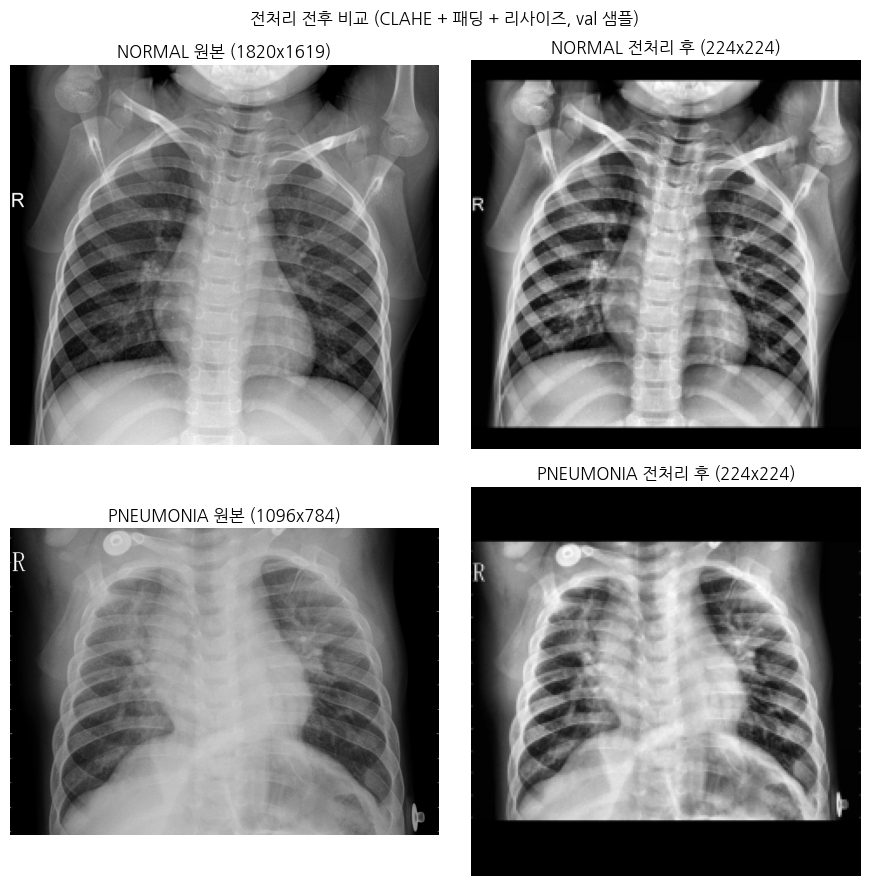

In [11]:
def load_preprocess_pair(path: Path) -> tuple[np.ndarray, np.ndarray]:
    """원본 그레이스케일과 CLAHE+패딩+리사이즈 적용본을 함께 반환한다."""
    raw = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if raw is None:
        raise FileNotFoundError(f"이미지 로드 실패: {path}")

    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID)
    processed = clahe.apply(raw)
    processed = pad_to_square(processed)
    processed = cv2.resize(processed, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    return raw, processed


sample_paths = {
    "NORMAL": next(p for p, y in zip(val_dataset.image_paths, val_dataset.labels) if y == 0),
    "PNEUMONIA": next(p for p, y in zip(val_dataset.image_paths, val_dataset.labels) if y == 1),
}

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for row, (cls_name, sample_path) in enumerate(sample_paths.items()):
    raw, processed = load_preprocess_pair(sample_path)
    axes[row][0].imshow(raw, cmap="gray")
    axes[row][0].set_title(f"{cls_name} 원본 ({raw.shape[1]}x{raw.shape[0]})")
    axes[row][1].imshow(processed, cmap="gray")
    axes[row][1].set_title(f"{cls_name} 전처리 후 ({IMAGE_SIZE}x{IMAGE_SIZE})")
    for ax in axes[row]:
        ax.axis("off")

fig.suptitle("전처리 전후 비교 (CLAHE + 패딩 + 리사이즈, val 샘플)")
fig.tight_layout()
plt.show()

### B-e. 데이터 준비 결과 정리

- 재분배 결과가 미션 06 기록과 완전히 일치:
  train 4,185장(NORMAL 1,079 / PNEUMONIA 3,106), val 1,047장(270 / 777), test 624장(234 / 390).
- 클래스 가중치도 미션 06과 동일하게 NORMAL 1.9393 / PNEUMONIA 0.6737로 산출되었습니다.
- 배치 검증: `(64, 3, 224, 224)` float32, ImageNet 정규화 범위 내로 이상 없습니다.
- 전처리 시각화에서 CLAHE에 의한 대비 보정과 검은색 패딩에 의한 정방형 변환이 확인되었습니다.

데이터 파이프라인이 미션 06과 동등함이 확인되었으므로, 섹션 C에서 모델 학습을 진행하겠습니다.

## C. 모델 학습

### C-a. 계획 확인

- 모델: `mobilenet_v3_large`를 사용합니다.  
  PTQ에서 `fuse_model()`을 그대로 재사용하기 위해  
  **양자화 대응 변형을 처음부터 사용**합니다. (ImageNet 사전학습 가중치 로드).
- 학습 목표: 최고 성능 재현이 아닌 **포맷 변환 파이프라인 검증용 기준 모델**을 확보합니다.  
  이번 미션의 1차 학습(5 epoch)에서 test 특이도가 21%로 낮게 측정되었기 때문에, (정상을 폐렴으로 79% 오진, 위양성)  
  기준선 보강을 위해 **최대 15 epoch + 조기 종료(개선 없음 3 epoch)** 로 학습을 진행합니다.
- 분류 헤드: `classifier` 최종 Linear를 2분류로 교체합니다: 정상-폐렴의 이진 분류
- 학습 설정: AdamW(lr 1e-4), 클래스 가중치 적용 CrossEntropy, BF16 AMP (과정 공통 규약).
- 지표: **val Recall(폐렴) 우선**, confusion matrix 병행,
  best 체크포인트 선택 기준은 (val Recall, val accuracy) 사전식으로 비교합니다.

### C-b. 모델 준비

#### C-b-1. 사전학습 가중치 로드 및 분류 헤드 교체

In [ ]:
from torchvision.models import MobileNet_V3_Large_Weights
from torchvision.models.quantization import mobilenet_v3_large


def build_model(num_classes: int = NUM_CLASSES) -> nn.Module:
    """양자화 대응 MobileNetV3-Large를 로드하고 분류 헤드를 교체한다.

    섹션 E의 PTQ에서 fuse_model()을 재사용하기 위해
    torchvision 양자화 대응 변형(quantize=False)을 사용한다.
    """
    model = mobilenet_v3_large(
        weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1,
        quantize=False,
    )
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    return model

ONE_MILLION = 1_000_000
model = build_model().to(device)
total_params = sum(p.numel() for p in model.parameters())
logger.info(f"모델 준비 완료 — 파라미터 {total_params / ONE_MILLION:.2f}M")

[16:33:57] [INFO] 모델 준비 완료 — 파라미터 4.20M


#### C-b-2. 더미 배치 forward 확인

In [13]:
model.eval()
with torch.no_grad():
    dummy_out = model(torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE, device=device))

print(f"더미 배치 출력 shape: {tuple(dummy_out.shape)}")
assert dummy_out.shape == (4, NUM_CLASSES), "출력 형상이 [batch, 2]가 아닙니다."
print("더미 forward 검증 통과")

더미 배치 출력 shape: (4, 2)
더미 forward 검증 통과


### C-c. 학습 파이프라인

#### C-c-1. 평가 함수 및 혼동행렬 시각화 구현

FN(False Negative,폐렴을 정상으로 판정)을 항상 함께 산출하겠습니다.  
혼동행렬의 FN 칸은 강조 표기합니다.

In [14]:
from sklearn.metrics import confusion_matrix


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    eval_device: torch.device | None = None,
) -> dict:
    """손실과 함께 accuracy / Recall(폐렴) / FN / 혼동행렬을 계산한다.

    eval_device 미지정 시 전역 device를 사용한다. INT8 모델은 CPU를 지정할 것.
    """
    if eval_device is None:
        eval_device = device
    model.eval()
    total_loss = 0.0
    all_preds: list[int] = []
    all_targets: list[int] = []

    for xb, yb in loader:
        xb = xb.to(eval_device, non_blocking=True)
        yb = yb.to(eval_device, non_blocking=True)
        with torch.autocast(device_type=eval_device.type, dtype=torch.bfloat16, enabled=(eval_device.type == "cuda")):
            logits = model(xb)
            loss = criterion(logits, yb)
        total_loss += loss.item() * yb.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().tolist())
        all_targets.extend(yb.cpu().tolist())

    cm = confusion_matrix(all_targets, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    # numpy 스칼라는 torch.load(weights_only=True)가 거부하므로 파이썬 기본 타입으로 변환
    return {
        "loss": float(total_loss / cm.sum()),
        "accuracy": float((tn + tp) / cm.sum()),
        "recall": float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0,
        "fn": int(fn),
        "cm": cm,
    }


def plot_confusion_matrix(cm: np.ndarray, title: str, ax=None) -> None:
    """혼동행렬을 히트맵으로 그린다. FN 칸(폐렴→정상 오판)은 강조 표기한다."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES)
    ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
    ax.set_xlabel("예측")
    ax.set_ylabel("실제")
    ax.set_title(title)
    threshold = cm.max() / 2
    for row in range(NUM_CLASSES):
        for col in range(NUM_CLASSES):
            note = " (FN)" if (row == 1 and col == 0) else ""
            ax.text(
                col, row, f"{cm[row, col]}{note}",
                ha="center", va="center",
                color="white" if cm[row, col] > threshold else "black",
            )


logger.info("평가 함수 준비 완료")

[16:33:58] [INFO] 평가 함수 준비 완료


#### C-c-2. 학습 루프 구현 (BF16 AMP + 조기 종료 + best 체크포인트)

In [15]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
) -> float:
    """1 epoch 학습을 수행하고 평균 손실을 반환한다."""
    model.train()
    total_loss = 0.0
    n_samples = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=(device.type == "cuda")):
            logits = model(xb)
            loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * yb.size(0)
        n_samples += yb.size(0)

    return total_loss / n_samples


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    patience: int,
    ckpt_path: Path,
) -> dict:
    """조기 종료와 best 체크포인트 저장을 포함한 학습을 수행한다.

    best 선택 기준: (val Recall(폐렴), val accuracy) 사전식 비교.
    """
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    history: dict[str, list] = {
        "train_loss": [], "val_loss": [], "val_accuracy": [], "val_recall": [], "val_fn": [],
    }
    best_key = (-1.0, -1.0)
    best_epoch = 0
    no_improve = 0

    for epoch in range(1, epochs + 1):
        start = time.perf_counter()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = evaluate(model, val_loader, criterion)
        elapsed = time.perf_counter() - start

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_recall"].append(val_metrics["recall"])
        history["val_fn"].append(val_metrics["fn"])

        logger.info(
            f"[{epoch:02d}/{epochs}] train_loss {train_loss:.4f} | "
            f"val_loss {val_metrics['loss']:.4f} acc {val_metrics['accuracy']:.4f} "
            f"recall {val_metrics['recall']:.4f} FN {val_metrics['fn']} | {elapsed:.1f}s"
        )

        current_key = (val_metrics["recall"], val_metrics["accuracy"])
        if current_key > best_key:
            best_key = current_key
            best_epoch = epoch
            no_improve = 0
            torch.save(
                {
                    "epoch": epoch,
                    "state_dict": model.state_dict(),
                    "metrics": {k: v for k, v in val_metrics.items() if k != "cm"},
                },
                ckpt_path,
            )
            logger.info(f"  best 갱신 (epoch {epoch}) — 체크포인트 저장")
        else:
            no_improve += 1
            if no_improve >= patience:
                logger.info(f"조기 종료 — {patience} epoch 연속 개선 없음")
                break

    return {"history": history, "best_epoch": best_epoch}

#### C-c-3. 학습 실행

이미 학습된 체크포인트가 있으면 재사용하도록 합니다.(노트북 반복 실행 대비)  
`FORCE_RETRAIN = True`로 설정하면 처음부터 학습합니다.

In [16]:
EPOCHS = 15
PATIENCE = 3
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
CKPT_PATH = CKPT_DIR / "mobilenetv3_best.pth"
HISTORY_PATH = CKPT_DIR / "train_history.json"

FORCE_RETRAIN = False

if CKPT_PATH.exists() and HISTORY_PATH.exists() and not FORCE_RETRAIN:
    with open(HISTORY_PATH, encoding="utf-8") as f:
        saved = json.load(f)
    history = saved["history"]
    best_epoch = saved["best_epoch"]
    logger.info(f"기존 체크포인트 재사용 — best epoch {best_epoch} ({CKPT_PATH})")
else:
    fix_seed()
    result = fit(model, train_loader, val_loader, EPOCHS, PATIENCE, CKPT_PATH)
    history = result["history"]
    best_epoch = result["best_epoch"]
    with open(HISTORY_PATH, "w", encoding="utf-8") as f:
        json.dump({"history": history, "best_epoch": best_epoch}, f, ensure_ascii=False, indent=2)
    logger.info(f"학습 완료 — best epoch {best_epoch}")

[16:35:14] [INFO] [01/15] train_loss 0.1886 | val_loss 0.6077 acc 0.8367 recall 1.0000 FN 0 | 73.7s


[16:35:14] [INFO]   best 갱신 (epoch 1) — 체크포인트 저장


[16:36:27] [INFO] [02/15] train_loss 0.0592 | val_loss 0.4046 acc 0.8911 recall 1.0000 FN 0 | 71.1s


[16:36:27] [INFO]   best 갱신 (epoch 2) — 체크포인트 저장


[16:37:41] [INFO] [03/15] train_loss 0.0429 | val_loss 0.2023 acc 0.9522 recall 1.0000 FN 0 | 71.9s


...

[16:38:57] [INFO] [04/15] train_loss 0.0253 | val_loss 0.2403 acc 0.9446 recall 1.0000 FN 0 | 76.1s


[16:40:13] [INFO] [05/15] train_loss 0.0259 | val_loss 0.2090 acc 0.9532 recall 0.9987 FN 1 | 76.4s


[16:41:28] [INFO] [06/15] train_loss 0.0255 | val_loss 0.0402 acc 0.9857 recall 0.9897 FN 8 | 75.0s


[16:41:28] [INFO] 조기 종료 — 3 epoch 연속 개선 없음


[16:41:28] [INFO] 학습 완료 — best epoch 3


### C-d. 학습 결과

#### C-d-1. 학습 곡선

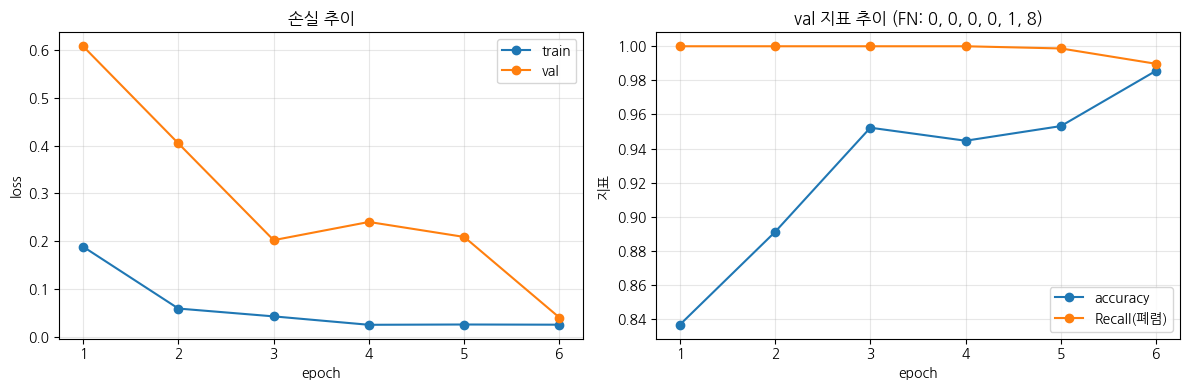

In [17]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("손실 추이")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["val_accuracy"], marker="o", label="accuracy")
axes[1].plot(epochs_range, history["val_recall"], marker="o", label="Recall(폐렴)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("지표")
axes[1].set_title("val 지표 추이 (FN: " + ", ".join(str(v) for v in history["val_fn"]) + ")")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

#### C-d-2. best 모델 val 지표 및 혼동행렬

best epoch       : 3
val accuracy     : 0.9522
val Recall(폐렴) : 1.0000
val FN           : 0 / 777


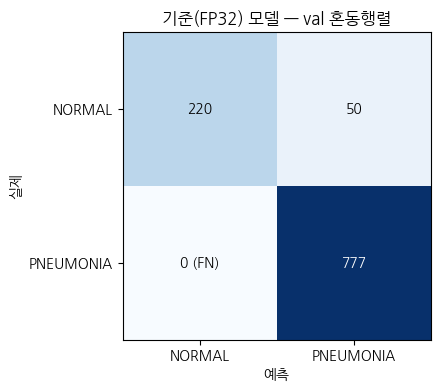

In [ ]:
checkpoint = torch.load(CKPT_PATH, map_location=device)
best_model = build_model().to(device)
best_model.load_state_dict(checkpoint["state_dict"])

criterion_eval = nn.CrossEntropyLoss(weight=class_weights.to(device))
val_best = evaluate(best_model, val_loader, criterion_eval)

print(f"best epoch       : {checkpoint['epoch']}")
print(f"val accuracy     : {val_best['accuracy']:.4f}")
print(f"val Recall(폐렴) : {val_best['recall']:.4f}")
print(f"val FN           : {val_best['fn']} / {int(val_best['cm'][1].sum())}")

plot_confusion_matrix(val_best["cm"], "기준(FP32) 모델 : val 혼동행렬")
plt.show()

### C-e. 기준 모델 분석 및 확정

- 15 epoch 연장 운용 결과 epoch 6에서 조기 종료되었고,  
  **best는 epoch 3**으로 결정되었습니다.(이전과 동일)  
  val accuracy 0.9522, Recall(폐렴) 1.0000, FN 0 / 777 으로 유지되었습니다.
- epoch 6은 val accuracy 0.9857로 가장 높았으나 **FN 8건(Recall 0.9897)** 이 발생했습니다.(위음성 발생)  
  미션 06 원칙인 "accuracy가 올라도 FN(=Recall 저하)이 늘면 개악(폐렴의 빠른 진단 우선)" 에 따라 배제합니다.  
  학습이 진행될수록 특이도 상승과 Recall 하락이 맞교환되는 양상이 관찰되며,  
  이는 (Recall, accuracy) 사전식 선택 기준이 실제로 작동함을 보여줍니다.
- 기준 모델 확정: **epoch 3 체크포인트**를 선택합니다 → Recall 1.0 / FN 0을 유지하는 지점 중 최고 accuracy.  
  이후 섹션 D~F에서 이 모델을 3종 포맷으로 추출하고,  
  양자화(E)·ONNX(F) 전후의 Recall·FN 변화를 test 624장 기준으로 측정하겠습니다.

## D. FP32 pth 추출

### D-a. 계획 확인

- 저장 방식: `model.eval()` 후 **`state_dict`를 저장**
- 파일명·경로: `models/mission_16_mobilenetv3.pth`.
- 검증: 새 모델 인스턴스에 재로드하여 동일 입력에 대한 출력 일치(`torch.allclose`)를 확인하고 파일 크기를 기록합니다.

### D-b. state_dict 저장

In [ ]:
FP32_PATH = MODELS_DIR / "mission_16_mobilenetv3.pth"

best_model.eval()
torch.save(best_model.state_dict(), FP32_PATH)

fp32_size_mb = FP32_PATH.stat().st_size / (1024 * 1024)
logger.info(f"FP32 state_dict 저장: {FP32_PATH} ({fp32_size_mb:.2f} MB)")

[16:41:42] [INFO] FP32 state_dict 저장: models/mission_16_mobilenetv3.pth (16.24 MB)


### D-c. 재로드 및 출력 일치 검증

In [20]:
reloaded_model = build_model().to(device)
reloaded_model.load_state_dict(torch.load(FP32_PATH, map_location=device))
reloaded_model.eval()

fix_seed()
probe = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
with torch.no_grad():
    out_original = best_model(probe)
    out_reloaded = reloaded_model(probe)

max_diff = (out_original - out_reloaded).abs().max().item()
print(f"원본 vs 재로드 최대 오차: {max_diff:.2e}")
assert torch.allclose(out_original, out_reloaded), "재로드 출력이 원본과 일치하지 않습니다."
print("FP32 재로드 검증 통과")

원본 vs 재로드 최대 오차: 0.00e+00


FP32 재로드 검증 통과


### D-d. FP32 추출 결과 정리

- `models/mission_16_mobilenetv3.pth` **16.24 MB** (`state_dict`) 저장 완료.
- 새 인스턴스 재로드 후 동일 입력 출력 **최대 오차 0.00** (`torch.allclose` 통과) : 가중치 무손실 보존을 확인했습니다.
- 파라미터 4.20M × 4 byte ≈ 16.8 MB 이론치와 부합하는 크기입니다.

## E. INT8 양자화 pth 추출 (PTQ)

### E-a. 계획 확인

- 방식: **PTQ(정적 양자화, eager mode)**
  - `fuse_model()`
  - `fbgemm` qconfig
  - `prepare`
  - 보정(calibration)
  - `convert`
  - SE 블록, hardswish 등 MobileNetV3 자체의 양자화 이슈는 torchvision 양자화 대응 변형이 내부에서 처리합니다.
- 보정 데이터: train 서브셋 300장, **클래스별 150장 균형 추출** (시드 42 고정, 증강 없는 결정적 전처리)  
  보정 분포가 입력 분포를 대표해야 activation 스케일이 올바르게 잡힙니다. (실제 값을 측정하여 INT8의 적용 범위 설정)
- 저장: 변환 모델을 `torch.jit.script`로 스크립트화하여 `.pth`로 저장합니다.  
  inference 노트북에서 클래스 정의 없이 단일 파일로 로드하기 위해서입니다.
- 백엔드: `fbgemm` (x86 로컬 기준)로 설정합니다.  
  백엔드별 지원 연산과 성능이 다르기 때문에, 모바일 배포 시 `qnnpack`으로 교체해야 합니다.
- deprecated 경고: `torch.ao.quantization`과 `torch.jit.script`는 torch 2.10에서
  deprecated 경고를 출력하나 동작은 정상입니다.
- 실패 시 폴백
  ① FX graph mode(`quantize_fx`)
  ② ResNet18 교체

### E-b. 보정(calibration) 데이터 구성

In [ ]:
CALIB_SIZE = 300

# 클래스별 균형 추출 (시드 고정으로 재현 가능)
rng = np.random.default_rng(SEED)
train_label_arr = np.array(train_labels)
calib_indices: list[int] = []
for cls_idx in range(NUM_CLASSES):
    cls_positions = np.where(train_label_arr == cls_idx)[0]
    chosen = rng.choice(cls_positions, size=CALIB_SIZE // NUM_CLASSES, replace=False)
    calib_indices.extend(chosen.tolist())

calib_paths = [train_paths[i] for i in calib_indices]
calib_labels = [train_labels[i] for i in calib_indices]

# 보정은 증강 없는 결정적 전처리로 수행합니다
calib_dataset = ChestXrayDataset(calib_paths, calib_labels, is_train=False)
calib_loader = build_loader(calib_dataset, shuffle=False)
logger.info(f"보정 데이터: {len(calib_dataset)}장 (분포: {Counter(calib_labels)})")

[16:41:42] [INFO] 보정 데이터: 300장 (분포: Counter({0: 150, 1: 150}))


### E-c. fuse → prepare → 보정 → convert

In [ ]:
# 양자화는 CPU(fbgemm) 기준으로 수행합니다. + GPU(cuquant) 양자화는 torch 2.3 이상에서 지원됩니다.
quant_model = build_model()
quant_model.load_state_dict(torch.load(FP32_PATH, map_location="cpu"))
quant_model.eval()

quant_model.fuse_model(is_qat=False)
quant_model.qconfig = torch.ao.quantization.get_default_qconfig("fbgemm")
torch.ao.quantization.prepare(quant_model, inplace=True)

with torch.no_grad():
    for xb, _ in calib_loader:
        quant_model(xb)

torch.ao.quantization.convert(quant_model, inplace=True)
logger.info("PTQ 변환 완료 (fbgemm, 보정 300장)")

/tmp/ipykernel_177308/3296070643.py:8: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.ao.quantization.prepare(quant_model, inplace=True)
/mnt/wsl_data/miniforge3/envs/ai/lib/python3.12/site-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be depr

/tmp/ipykernel_177308/3296070643.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.ao.quantization.convert(quant_model, inplace=True)
/mnt/wsl_data/miniforge3/envs/ai/lib/python3.12/site-packages/torch/ao/nn/quantized/modules/functional_modules.py:294: UserWarning: must run observer before calling calculate_qparams.                                    Returning d

[16:41:55] [INFO] PTQ 변환 완료 (fbgemm, 보정 300장)


### E-d. TorchScript 저장 및 재로드 검증

In [ ]:
INT8_PATH = MODELS_DIR / "mission_16_mobilenetv3_quant.pth"

scripted = torch.jit.script(quant_model)
scripted.save(str(INT8_PATH))

int8_size_mb = INT8_PATH.stat().st_size / (1024 * 1024)
logger.info(
    f"INT8 TorchScript 저장: {INT8_PATH} ({int8_size_mb:.2f} MB, "
    f"FP32 대비 {fp32_size_mb / int8_size_mb:.2f}배 압축)"
)

int8_model = torch.jit.load(str(INT8_PATH), map_location="cpu")
int8_model.eval()

probe_cpu = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)
with torch.no_grad():
    out_int8 = int8_model(probe_cpu)

print(f"재로드 추론 출력 shape: {tuple(out_int8.shape)}")
assert out_int8.shape == (2, NUM_CLASSES), "INT8 재로드 출력 형상이 기대와 다릅니다."
print("INT8 재로드 검증 통과")

[16:41:55] [INFO] INT8 TorchScript 저장: models/mission_16_mobilenetv3_quant.pth (4.47 MB, FP32 대비 3.64배 압축)


재로드 추론 출력 shape: (2, 2)
INT8 재로드 검증 통과


### E-e. test set 평가 - FP32 vs INT8

양자화 열화를 test 624장 기준으로 측정합니다.  
공정 비교를 위해 두 모델 모두 CPU에서 평가합니다.

지표                   FP32       INT8
accuracy           0.7051     0.6891
Recall(폐렴)         1.0000     1.0000
FN                      0          0


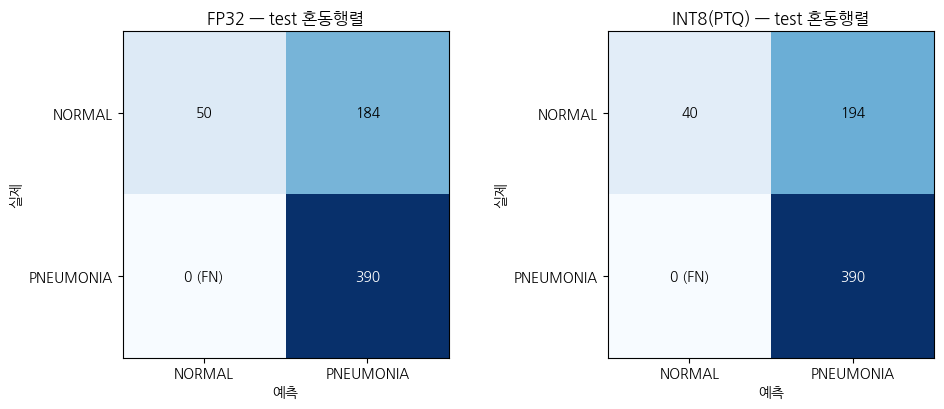

In [24]:
cpu_device = torch.device("cpu")
criterion_cpu = nn.CrossEntropyLoss(weight=class_weights)

fp32_cpu = build_model()
fp32_cpu.load_state_dict(torch.load(FP32_PATH, map_location="cpu"))
fp32_cpu.eval()

test_fp32 = evaluate(fp32_cpu, test_loader, criterion_cpu, cpu_device)
test_int8 = evaluate(int8_model, test_loader, criterion_cpu, cpu_device)

print(f"{'지표':<14} {'FP32':>10} {'INT8':>10}")
print(f"{'accuracy':<14} {test_fp32['accuracy']:>10.4f} {test_int8['accuracy']:>10.4f}")
print(f"{'Recall(폐렴)':<14} {test_fp32['recall']:>10.4f} {test_int8['recall']:>10.4f}")
print(f"{'FN':<14} {test_fp32['fn']:>10} {test_int8['fn']:>10}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
plot_confusion_matrix(test_fp32["cm"], "FP32 — test 혼동행렬", ax=axes[0])
plot_confusion_matrix(test_int8["cm"], "INT8(PTQ) — test 혼동행렬", ax=axes[1])
fig.tight_layout()
plt.show()

### E-f. 양자화 결과 정리

- `models/mission_16_mobilenetv3_quant.pth` **4.47 MB** → FP32 대비 **3.64배 압축**.  
  이론치(4배)와의 차이는 양자화 제외 연산과 TorchScript 메타데이터에서 기인합니다.
- test 624장 비교: accuracy 0.7051 → 0.6891(−1.60%p), **Recall(폐렴) 1.0 → 1.0, FN 0 → 0**.
- 양자화 열화가 전부 FP(정상 → 폐렴) 방향으로만 발생했고 FN은 증가하지 않았습니다.  
  위음성 최소화가 최우선인 의료 도메인에서 안전한 방향의 열화이며,  
  보정 데이터 확대·QAT 검토가 필요한 수준(FN 증가)에 해당하지 않습니다.
- val(95.2%) 대비 test(70.5%) 정확도 하락은 이 데이터셋의 알려진 분포 차이입니다.  
  미션 06에서도 4개 모델 전부 test 특이도가 45~54%에 그쳤다(MobileNetV3 test acc 82.5%).  
  연장 학습으로 특이도를 올리는 시도는 Recall 하락(FN 8)과 맞교환되어 배제되었습니다.  
  우선 지표인 Recall·FN은 미션 06 최적 모델(EfficientNet-B0: Recall 1.0, FN 0)과 동일 수준이며  
  **포맷 변환 전후 비교라는 본 미션 목적에 충분한 기준선**입니다.

## F. ONNX 추출 및 검증

### F-a. 계획 확인

- export 대상: FP32 기준 모델 (`model.eval()`, dropout 비활성).
- 조건: **opset 17, Fixed Shape `(1, 3, 224, 224)`** (batch 차원 고정).
- exporter: opset 17 요구사항에 맞춰 **레거시 TorchScript 기반 exporter**(`dynamo=False`)를 사용합니다.  
  torch 2.9부터 dynamo 기반 exporter가 기본이나 이는 opset 18 이상을 대상으로 하며,  
  레거시 경로는 deprecated 경고를 출력하되 정상 동작함을 사전 검증했습니다.
- 검증 순서
  - 구조(`onnx.checker`)
  - 런타임(`onnxruntime` 세션)
  - 수치 일치(`np.allclose`, atol=1e-4, 최대 오차 기록)

### F-b. torch.onnx.export 실행

In [ ]:
ONNX_PATH = MODELS_DIR / "mission_16_mobilenetv3.onnx"

export_model = build_model()
export_model.load_state_dict(torch.load(FP32_PATH, map_location="cpu"))
export_model.eval()

fix_seed()
dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)

# opset 17 지원을 위해 레거시 TorchScript exporter를 명시적으로 사용합니다.
# + torch 2.6 이상에서는 torch.onnx.export()가 자동으로 legacy exporter를 사용합니다.
torch.onnx.export(
    export_model,
    dummy_input,
    str(ONNX_PATH),
    opset_version=17,
    input_names=["input"],
    output_names=["logits"],
    do_constant_folding=True,
    dynamo=False,
)

onnx_size_mb = ONNX_PATH.stat().st_size / (1024 * 1024)
logger.info(f"ONNX 저장: {ONNX_PATH} ({onnx_size_mb:.2f} MB)")

/tmp/ipykernel_177308/3309527731.py:11: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


[16:42:23] [INFO] ONNX 저장: models/mission_16_mobilenetv3.onnx (16.03 MB)


### F-c. 구조, 런타임, 수치 일치 검증

In [ ]:
onnx_model = onnx.load(str(ONNX_PATH))
onnx.checker.check_model(onnx_model)
input_shape = [d.dim_value for d in onnx_model.graph.input[0].type.tensor_type.shape.dim]
print(f"onnx.checker 구조 검증 통과 : 입력 '{onnx_model.graph.input[0].name}' shape {input_shape}")
assert input_shape == [1, 3, IMAGE_SIZE, IMAGE_SIZE], "Fixed Shape (1,3,224,224)가 아닙니다."

sess = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])

fix_seed()
probe_onnx = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
with torch.no_grad():
    torch_out = export_model(probe_onnx).numpy()
ort_out = sess.run(None, {"input": probe_onnx.numpy()})[0]

max_err = np.abs(torch_out - ort_out).max()
print(f"PyTorch vs ONNX 최대 오차: {max_err:.2e}")
assert np.allclose(torch_out, ort_out, atol=1e-4), "PyTorch와 ONNX 출력이 일치하지 않습니다."
print("수치 일치 검증 통과 (atol=1e-4)")

onnx.checker 구조 검증 통과 — 입력 'input' shape [1, 3, 224, 224]
PyTorch vs ONNX 최대 오차: 1.43e-06
수치 일치 검증 통과 (atol=1e-4)


### F-d. 3종 포맷 추출 결과 정리

In [27]:
print(f"{'파일':<38} {'크기(MB)':>10}")
for model_path in sorted(MODELS_DIR.glob("mission_16_*")):
    print(f"{model_path.name:<38} {model_path.stat().st_size / 2**20:>10.2f}")

파일                                         크기(MB)
mission_16_mobilenetv3.onnx                 16.03
mission_16_mobilenetv3.pth                  16.24
mission_16_mobilenetv3_quant.pth             4.47


- ONNX **16.03 MB**, 구조 검증 통과, 입력 `input` Fixed Shape `(1, 3, 224, 224)`.
- PyTorch 대비 **최대 오차 1.43e-06** — `np.allclose(atol=1e-4)` 통과
- 3종 포맷 추출 완료: FP32 16.24 MB / INT8 4.47 MB / ONNX 16.03 MB.